# Smart Water Analyzer
Part 1: **data preprocessing**. Part 2: **Linear Regression** and **CART** model training.

Run every cell top to bottom. It writes `dataset/water_consumption_clean.csv`, which `app.py` uses to train the same two models when the web app starts. No `.pkl` files are used.

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix

ACTIVITIES = ["Bathroom", "Kitchen", "Laundry", "Gardening"]

# Part 1: Data preprocessing
## Step 1. Load and inspect the raw data

In [3]:
raw = pd.read_csv("dataset/water_consumption.csv")
df = raw.copy()

print("Shape:", df.shape)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("Negative values:", (df[ACTIVITIES + ["Total"]] < 0).sum().sum())
df.describe().round(1)

Shape: (610, 5)

Missing values per column:
 Bathroom     2
Kitchen      6
Laundry      1
Gardening    6
Total        6
dtype: int64

Duplicate rows: 10
Negative values: 4


,Bathroom,Kitchen,Laundry,Gardening,Total
count,608.0,604.0,609.0,604.0,604.0
mean,118.5,69.6,58.1,82.5,332.3
std,35.3,19.7,23.5,61.7,78.3
min,-129.2,15.0,-72.7,-100.6,140.1
25%,95.4,57.0,44.0,47.4,281.8
50%,118.2,70.2,58.9,81.4,330.6
75%,140.3,82.3,73.3,107.6,371.0
max,222.0,133.6,124.1,520.0,835.7


## Step 2. Tidy column names and force numeric types

In [4]:
df.columns = df.columns.str.strip().str.title()
for col in ACTIVITIES + ["Total"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")   # text or bad entries become NaN
df.dtypes

Bathroom     float64
Kitchen      float64
Laundry      float64
Gardening    float64
Total        float64
dtype: object

## Step 3. Remove duplicate rows

In [5]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicates removed:", before - len(df))

Duplicates removed: 10


## Step 4. Fix invalid values
Water used can never be negative, so negative readings are treated as missing.

In [6]:
neg_mask = df[ACTIVITIES + ["Total"]] < 0
print("Negative readings set to NaN:", int(neg_mask.sum().sum()))
df[ACTIVITIES + ["Total"]] = df[ACTIVITIES + ["Total"]].mask(neg_mask)

Negative readings set to NaN: 4


## Step 5. Handle missing values
- A missing activity value is filled with that column's **median** (the median is not pulled by extreme users).
- A missing `Total` is rebuilt as the **sum of the four activities**.

In [7]:
for col in ACTIVITIES:
    df[col] = df[col].fillna(df[col].median())

missing_total = df["Total"].isnull().sum()
df["Total"] = df["Total"].fillna(df[ACTIVITIES].sum(axis=1))
print("Totals rebuilt from activities:", missing_total)
print("Missing values left:", int(df.isnull().sum().sum()))

Totals rebuilt from activities: 6
Missing values left: 0


## Step 6. Consistency check
`Total` should be close to the sum of the four activities. Rows that differ by more than 15% are data-entry errors and are removed.

In [8]:
activity_sum = df[ACTIVITIES].sum(axis=1)
gap_pct = (df["Total"] - activity_sum).abs() / activity_sum * 100
bad = gap_pct > 15
print("Inconsistent rows removed:", int(bad.sum()))
df = df[~bad].reset_index(drop=True)

Inconsistent rows removed: 8


## Step 7. Remove outliers (IQR rule)
A value is an outlier when it is below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`.

In [9]:
cols = ACTIVITIES + ["Total"]
Q1, Q3 = df[cols].quantile(0.25), df[cols].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

is_outlier = ((df[cols] < lower) | (df[cols] > upper)).any(axis=1)
print("Outlier rows removed:", int(is_outlier.sum()))
print(pd.DataFrame({"lower": lower, "upper": upper}).round(1))
df = df[~is_outlier].reset_index(drop=True)

Outlier rows removed: 32
           lower  upper
Bathroom    29.1  207.1
Kitchen     20.4  119.5
Laundry      0.2  117.2
Gardening  -38.5  195.8
Total      157.7  496.2


## Step 8. Create the usage-level label
The CART model needs a target class. Total consumption is split into **Low / Medium / High** at the 33rd and 66th percentiles.

In [10]:
low_cut, high_cut = df["Total"].quantile([0.33, 0.66])

def usage_level(total):
    if total <= low_cut:  return "Low"
    if total <= high_cut: return "Medium"
    return "High"

df["Level"] = df["Total"].apply(usage_level)
print(f"Low <= {low_cut:.1f} L | Medium <= {high_cut:.1f} L | High above")
print(df["Level"].value_counts())

Low <= 299.5 L | Medium <= 350.6 L | High above
Level
High      191
Low       185
Medium    184
Name: count, dtype: int64


## Step 9. Before and after, then save
Scaling is not needed: Linear Regression fits raw litres directly, and a decision tree only compares values against thresholds.

In [11]:
round_cols = ACTIVITIES + ["Total"]
df[round_cols] = df[round_cols].round(1)

summary = pd.DataFrame({
    "Before": [len(raw), int(raw.isnull().sum().sum()), int(raw.duplicated().sum())],
    "After":  [len(df),  int(df.isnull().sum().sum()),  int(df.duplicated().sum())],
}, index=["Rows", "Missing cells", "Duplicate rows"])
print(summary)

df.to_csv("dataset/water_consumption_clean.csv", index=False)
print("\nSaved dataset/water_consumption_clean.csv")

                Before  After
Rows               610    560
Missing cells       21      0
Duplicate rows      10      0

Saved dataset/water_consumption_clean.csv


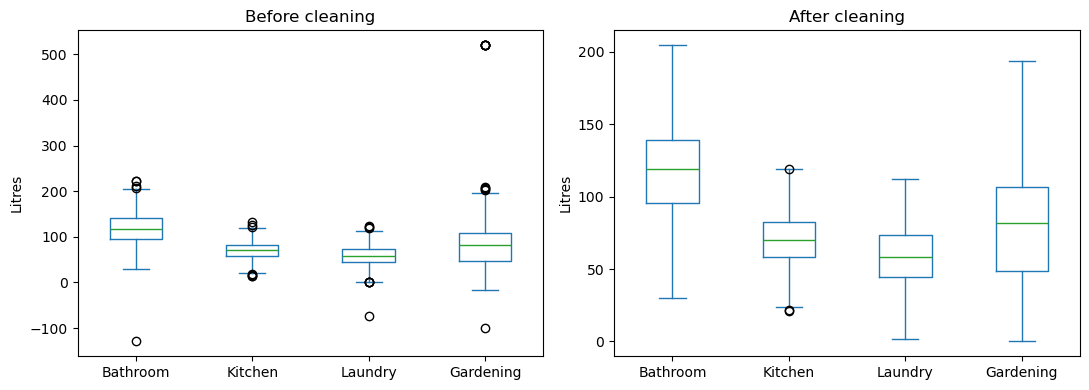

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
raw[ACTIVITIES].plot(kind="box", ax=axes[0], title="Before cleaning")
df[ACTIVITIES].plot(kind="box", ax=axes[1], title="After cleaning")
for a in axes: a.set_ylabel("Litres")
plt.tight_layout(); plt.show()

# Part 2: Model training
## Exploratory look at the clean data

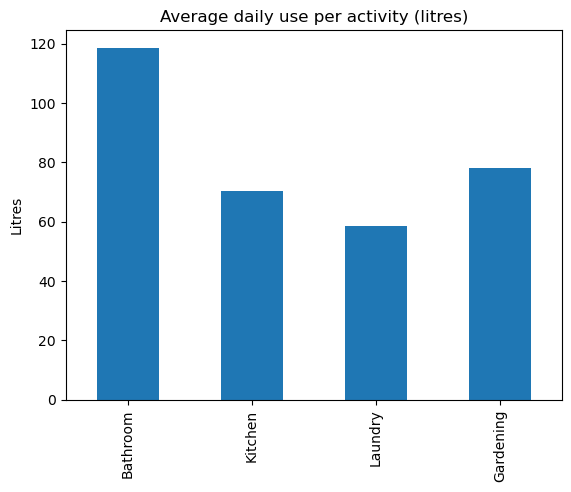

,Bathroom,Kitchen,Laundry,Gardening,Total
Bathroom,1.00,-0.06,-0.02,-0.03,0.53
Kitchen,-0.06,1.00,0.01,-0.03,0.27
Laundry,-0.02,0.01,1.00,-0.05,0.33
Gardening,-0.03,-0.03,-0.05,1.00,0.66
Total,0.53,0.27,0.33,0.66,1.00


In [13]:
df[ACTIVITIES].mean().plot(kind="bar", title="Average daily use per activity (litres)")
plt.ylabel("Litres"); plt.show()
df[ACTIVITIES + ["Total"]].corr().round(2)

## Linear Regression: predict total consumption

In [14]:
X = df[ACTIVITIES]
y = df["Total"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression().fit(X_train, y_train)
pred = lr.predict(X_test)

print("MAE :", round(mean_absolute_error(y_test, pred), 2), "litres")
print("R2  :", round(r2_score(y_test, pred), 4))
print("Equation: Total =", round(lr.intercept_, 2), "+",
      " + ".join(f"{c:.3f} x {n}" for n, c in zip(ACTIVITIES, lr.coef_)))

MAE : 5.85 litres
R2  : 0.981
Equation: Total = -0.37 + 1.006 x Bathroom + 1.008 x Kitchen + 0.990 x Laundry + 0.996 x Gardening


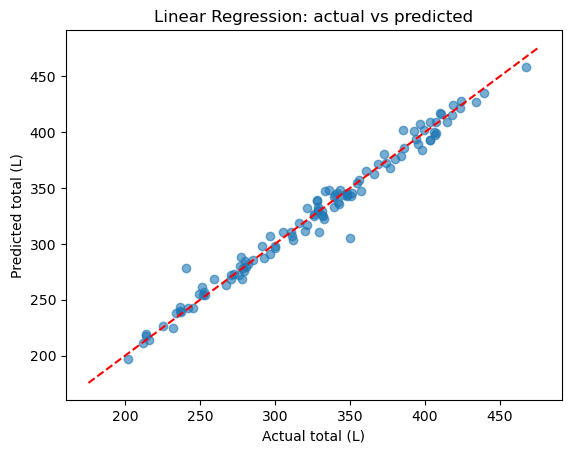

In [15]:
plt.scatter(y_test, pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.xlabel("Actual total (L)"); plt.ylabel("Predicted total (L)")
plt.title("Linear Regression: actual vs predicted"); plt.show()

## CART: classify usage level

In [16]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    df[ACTIVITIES], df["Level"], test_size=0.2, random_state=42, stratify=df["Level"])

cart = DecisionTreeClassifier(criterion="gini", max_depth=6, random_state=42).fit(Xc_train, yc_train)
yc_pred = cart.predict(Xc_test)

print("Accuracy:", round(accuracy_score(yc_test, yc_pred), 3))
print(classification_report(yc_test, yc_pred))
print(confusion_matrix(yc_test, yc_pred, labels=["Low", "Medium", "High"]))

Accuracy: 0.688
              precision    recall  f1-score   support

        High       0.85      0.76      0.81        38
         Low       0.74      0.68      0.70        37
      Medium       0.52      0.62      0.57        37

    accuracy                           0.69       112
   macro avg       0.70      0.69      0.69       112
weighted avg       0.70      0.69      0.69       112

[[25 12  0]
 [ 9 23  5]
 [ 0  9 29]]


|--- Gardening <= 64.35
|   |--- Bathroom <= 128.30
|   |   |--- Laundry <= 67.05
|   |   |   |--- Bathroom <= 114.55
|   |   |   |   |--- class: Low
|   |   |   |--- Bathroom >  114.55
|   |   |   |   |--- Gardening <= 55.90
|   |   |   |   |   |--- Bathroom <= 114.95
|   |   |   |   |   |   |--- class: Medium
|   |   |   |   |   |--- Bathroom >  114.95
|   |   |   |   |   |   |--- class: Low
|   |   |   |   |--- Gardening >  55.90
|   |   |   |   |   |--- Kitchen <= 71.60
|   |   |   |   |   |   |--- class: Low
|   |   |   |   |   |--- Kitchen >  71.60
|   |   |   |   |   |   |--- class: Medium
|   |   |--- Laundry >  67.05
|   |   |   |--- Kitchen <= 82.50
|   |   |   |   |--- Bathroom <= 117.20
|   |   |   |   |   |--- Kitchen <= 78.30
|   |   |   |   |   |   |--- class: Low
|   |   |   |   |   |--- Kitchen >  78.30
|   |   |   |   |   |   |--- class: Low
|   |   |   |   |--- Bathroom >  117.20
|   |   |   |   |   |--- Kitchen <= 76.65
|   |   |   |   |   |   |--- class: Medium
|  

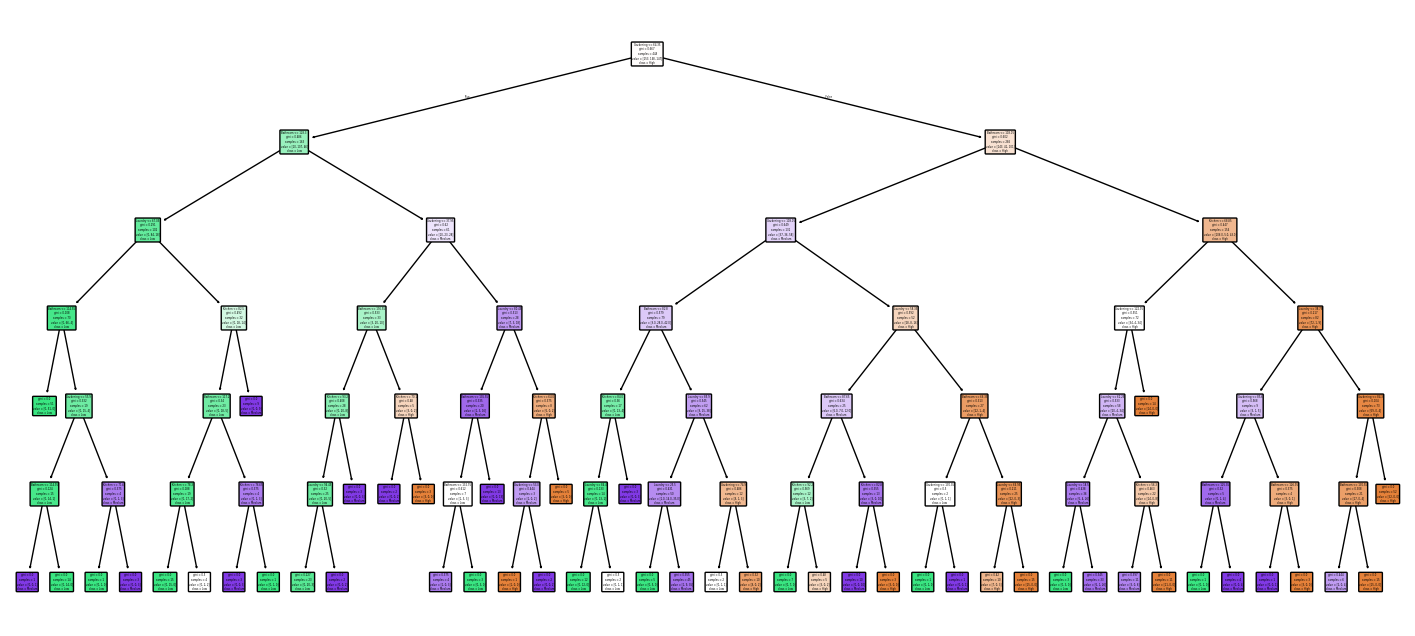

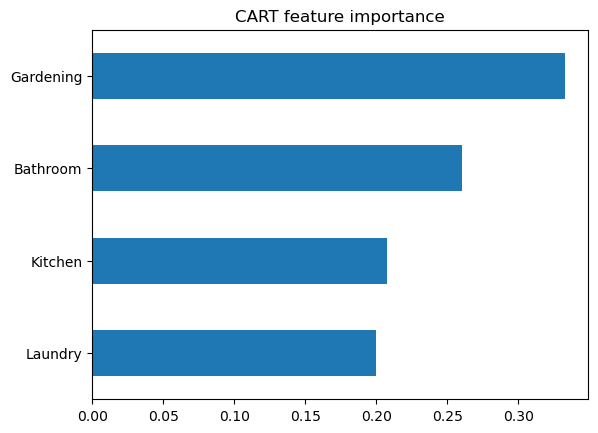

In [17]:
print(export_text(cart, feature_names=ACTIVITIES))
plt.figure(figsize=(18, 8))
plot_tree(cart, feature_names=ACTIVITIES, class_names=list(cart.classes_), filled=True, rounded=True)
plt.show()
pd.Series(cart.feature_importances_, index=ACTIVITIES).sort_values().plot(kind="barh", title="CART feature importance")
plt.show()

## Use in the web app
`app.py` reads `dataset/water_consumption_clean.csv` and trains these same two models when it starts, so there are no `.pkl` files to manage. Re-run this notebook whenever the raw dataset changes.